In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Load one stock's features to start
reliance = pd.read_csv('../data/features/RELIANCE_features.csv', 
                       index_col=0, parse_dates=True)
print(reliance.head())
print(reliance.shape)

                 close  daily_return        ma_7       ma_30  volatility_30  \
Date                                                                          
2019-02-12  556.129517      0.002514  567.236503  527.929060       0.017475   
2019-02-14  541.876526     -0.025629  563.018790  529.667148       0.018040   
2019-02-15  550.839966      0.016541  560.040475  531.905416       0.017934   
2019-02-18  540.061707     -0.019567  554.339957  533.697357       0.018462   
2019-02-19  538.291260     -0.003278  549.641689  535.340281       0.018501   

               rsi_14  
Date                   
2019-02-12  56.078330  
2019-02-14  45.505477  
2019-02-15  49.720691  
2019-02-18  48.344114  
2019-02-19  51.007624  
(1814, 6)


In [3]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
from prophet import Prophet
print("Prophet imported successfully")

Prophet imported successfully


In [6]:
# Prophet requires columns named 'ds' and 'y'
df_prophet = reliance[['close']].reset_index()
df_prophet.columns = ['ds', 'y']

print(df_prophet.head())
print(df_prophet.shape)

          ds           y
0 2019-02-12  556.129517
1 2019-02-14  541.876526
2 2019-02-15  550.839966
3 2019-02-18  540.061707
4 2019-02-19  538.291260
(1814, 2)


In [7]:
# Train Prophet model
model = Prophet(
    daily_seasonality=False,  # stock data doesn't have meaningful daily patterns
    weekly_seasonality=False, # markets are closed weekends, so weekly patterns are noise
    yearly_seasonality=True,  # yearly cycles (budget seasons, earnings quarters) are real
    changepoint_prior_scale=0.05  # controls how flexible the trend is - 0.05 is conservative
)

model.fit(df_prophet)

# Create future dataframe - forecast 90 days ahead
future = model.make_future_dataframe(periods=90, freq='B')  # 'B' = business days only

# Generate forecast
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

16:59:29 - cmdstanpy - INFO - Chain [1] start processing
16:59:30 - cmdstanpy - INFO - Chain [1] done processing


             ds         yhat   yhat_lower   yhat_upper
1894 2026-10-08  1522.950064  1432.430073  1614.273473
1895 2026-10-09  1522.826665  1433.555518  1610.332629
1896 2026-10-12  1523.345305  1440.969748  1613.465134
1897 2026-10-13  1523.795099  1438.157485  1610.926328
1898 2026-10-14  1524.362796  1439.678775  1617.821609
1899 2026-10-15  1525.030182  1432.356687  1614.082639
1900 2026-10-16  1525.775790  1437.202039  1609.740664
1901 2026-10-19  1528.232364  1432.827683  1617.211263
1902 2026-10-20  1529.035006  1433.932493  1616.493787
1903 2026-10-21  1529.784590  1442.502945  1617.485702


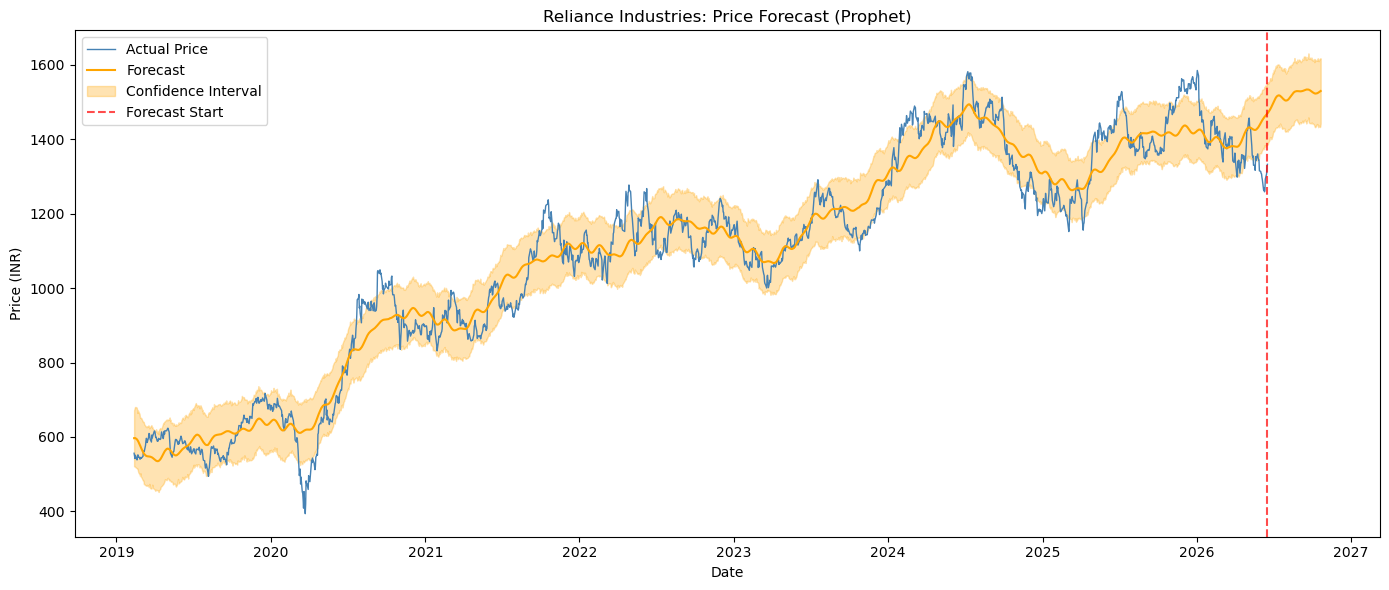

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual historical prices
ax.plot(df_prophet['ds'], df_prophet['y'], 
        label='Actual Price', color='steelblue', linewidth=1)

# Plot forecast line
ax.plot(forecast['ds'], forecast['yhat'], 
        label='Forecast', color='orange', linewidth=1.5)

# Plot confidence band
ax.fill_between(forecast['ds'], 
                forecast['yhat_lower'], 
                forecast['yhat_upper'], 
                alpha=0.3, color='orange', label='Confidence Interval')

# Mark where forecast starts
last_date = df_prophet['ds'].max()
ax.axvline(x=last_date, color='red', linestyle='--', alpha=0.7, label='Forecast Start')

ax.set_title('Reliance Industries: Price Forecast (Prophet)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Use last 90 days as test set
split_date = df_prophet['ds'].max() - pd.Timedelta(days=90)

train = df_prophet[df_prophet['ds'] <= split_date]
test = df_prophet[df_prophet['ds'] > split_date]

# Retrain on training data only
model_eval = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model_eval.fit(train)

# Forecast over the test period
future_eval = model_eval.make_future_dataframe(periods=len(test), freq='B')
forecast_eval = model_eval.predict(future_eval)

# Align forecast with test dates
forecast_test = forecast_eval[forecast_eval['ds'].isin(test['ds'])]

# Calculate RMSE and MAPE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['y'].values, forecast_test['yhat'].values))
mape = np.mean(np.abs((test['y'].values - forecast_test['yhat'].values) / test['y'].values)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


17:00:56 - cmdstanpy - INFO - Chain [1] start processing
17:00:57 - cmdstanpy - INFO - Chain [1] done processing


ValueError: Found input variables with inconsistent numbers of samples: [60, 56]

In [10]:
# Merge on dates instead of using .isin() to ensure perfect alignment
merged = pd.merge(
    test.rename(columns={'y': 'actual'}),
    forecast_eval[['ds', 'yhat']],
    on='ds',
    how='inner'  # only keep dates that exist in both
)

print(f"Aligned rows: {len(merged)}")

# Now calculate metrics on perfectly aligned data
rmse = np.sqrt(mean_squared_error(merged['actual'].values, merged['yhat'].values))
mape = np.mean(np.abs((merged['actual'].values - merged['yhat'].values) / merged['actual'].values)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Aligned rows: 56
RMSE: 128.44
MAPE: 8.36%


In [11]:
tickers = ['BHARTIARTL', 'HDFCBANK', 'HINDUNILVR', 'ICICIBANK', 
           'INFY', 'RELIANCE', 'TCS', 'TMPV']

results = {}

for ticker in tickers:
    # Load features
    df = pd.read_csv(f'../data/features/{ticker}_features.csv', 
                     index_col=0, parse_dates=True)
    
    # Prepare for Prophet
    df_p = df[['close']].reset_index()
    df_p.columns = ['ds', 'y']
    
    # Train/test split
    split_date = df_p['ds'].max() - pd.Timedelta(days=90)
    train = df_p[df_p['ds'] <= split_date]
    test = df_p[df_p['ds'] > split_date]
    
    # Train model
    m = Prophet(daily_seasonality=False, weekly_seasonality=False,
                yearly_seasonality=True, changepoint_prior_scale=0.05)
    m.fit(train)
    
    # Forecast
    future = m.make_future_dataframe(periods=90+len(test), freq='B')
    forecast = m.predict(future)
    
    # Evaluate
    merged = pd.merge(
        test.rename(columns={'y': 'actual'}),
        forecast[['ds', 'yhat']],
        on='ds', how='inner'
    )
    
    rmse = np.sqrt(mean_squared_error(merged['actual'].values, merged['yhat'].values))
    mape = np.mean(np.abs((merged['actual'].values - merged['yhat'].values) / merged['actual'].values)) * 100
    
    results[ticker] = {
        'model': m,
        'forecast': forecast,
        'rmse': round(rmse, 2),
        'mape': round(mape, 2)
    }
    
    print(f"{ticker}: RMSE={rmse:.2f}, MAPE={mape:.2f}%")

print("\nAll stocks forecasted successfully")

17:02:32 - cmdstanpy - INFO - Chain [1] start processing
17:02:33 - cmdstanpy - INFO - Chain [1] done processing


BHARTIARTL: RMSE=315.29, MAPE=16.99%


17:02:34 - cmdstanpy - INFO - Chain [1] start processing
17:02:35 - cmdstanpy - INFO - Chain [1] done processing


HDFCBANK: RMSE=220.92, MAPE=28.50%


17:02:36 - cmdstanpy - INFO - Chain [1] start processing
17:02:36 - cmdstanpy - INFO - Chain [1] done processing


...

RELIANCE: RMSE=134.87, MAPE=8.84%


17:02:43 - cmdstanpy - INFO - Chain [1] start processing
17:02:44 - cmdstanpy - INFO - Chain [1] done processing


TCS: RMSE=95.62, MAPE=3.31%


17:02:45 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing


TMPV: RMSE=91.59, MAPE=21.43%

All stocks forecasted successfully


In [12]:
import os
os.makedirs('../data/forecasts', exist_ok=True)

for ticker in tickers:
    results[ticker]['forecast'].to_csv(f'../data/forecasts/{ticker}_forecast.csv')

# Save summary metrics
metrics_df = pd.DataFrame({
    ticker: {'RMSE': results[ticker]['rmse'], 'MAPE': results[ticker]['mape']}
    for ticker in tickers
}).T

metrics_df.to_csv('../data/forecasts/forecast_metrics.csv')
print(metrics_df)

              RMSE   MAPE
BHARTIARTL  315.29  16.99
HDFCBANK    220.92  28.50
HINDUNILVR  109.93   4.47
ICICIBANK   161.14  12.20
INFY         44.52   2.94
RELIANCE    134.87   8.84
TCS          95.62   3.31
TMPV         91.59  21.43
